This notebook contains some exploration of the NNMF templates for the DESI Dwarf catalog

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Define normalization
import os
import random
import argparse
from astropy.table import Table, vstack
import h5py
import matplotlib as mpl
import sys

%load_ext autoreload
%autoreload 2

    
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

In [2]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'tight',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar



In [3]:
from desi_lowz_funcs import make_subplots

In [4]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")


In [5]:
data_cat[data_cat["TARGETID"]==39627486031516987]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,IS_BGS_BRIGHT,IS_BGS_FAINT,IS_LOWZ,IS_ELG,IS_OTHER,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,int32,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,int32,bytes13,bool,float64,float64[2],bool,bool,bool,bool,bool,bool,object,int64,bool,bytes10,int64
39627486031516987,main,bright,22584,0.041068888679545924,130.24864295870066,0,0.04085343000504915,66.40496910487605,-12.447804810692794,66.40496910487605,-12.447804810692794,DESI J066.4049-12.4478,186.60092163085938,9.199356079101562,0.06094374790614129,19.41065788269043,18.555870056152344,17.949480056762695,19.41065788269043,18.555870056152344,17.949480056762695,65536,0,TRACTOR_OG,False,2.0696022510528564,0.746579110622406 .. 151.76773071289062,False,True,False,False,False,False,[39627486031516987],39627486031516987,True,V_CMB,39627486031516987


In [6]:
# from astropy.io import fits

# with fits.open(filename) as hdul:
#     h = hdul["MAIN"]
#     i = h.columns.names.index("ZWARN")
#     print("TFORM:", h.columns[i].format)  # "1L" => logical (→ bool in Table)

In [16]:
h5_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/desi_dr1_dwarf_catalog_nnmf_pca_NEW.h5"
with h5py.File(h5_path, "r") as f:
    # pca_coeffs = f["PCA_COEFFS"][:]       # shape (N, 20)
    # nnmf_coeffs = f["NNMF_COEFFS"][:]     # shape (N, 10)
    tgids = f["TARGETID"][:]
    # norm_facs = f["NORM_FACTOR"][:]
    flux_norm = f["FLUX_NORM"][:]
    wave_rest = f["WAVE_REST"][:]
    # nnmf_rnorm = f["NNMF_RNORM"][:]
    

In [8]:
## load the nnmf templates !
nnmf_temps_NEW = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/nnmf_templates/templates_dwarfs_NEW.npy")

print(nnmf_temps_NEW.shape)



(3980, 10)


In [9]:
pca_temps_NEW = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/pca_components_NEW.npy")

print(pca_temps_NEW.shape)


(20, 3980)


In [10]:
# all_norm_resis = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/norm_residuals_dwarfs_v2.npy"  )

In [14]:
# import numpy as np
# import matplotlib.pyplot as plt

# # nnmf_coeffs has shape (465869, 10)
# corr = np.corrcoef(nnmf_coeffs.T)   # (10, 10)

# fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
# im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
# ax.set_xticks(range(10)); ax.set_yticks(range(10))
# ax.set_xticklabels([f"T{i+1}" for i in range(10)])
# ax.set_yticklabels([f"T{i+1}" for i in range(10)])
# for i in range(10):
#     for j in range(10):
#         ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center",
#                 color="black" if abs(corr[i,j]) < 0.6 else "white", fontsize=9)
# plt.colorbar(im, ax=ax, fraction=0.046)
# ax.set_title("NMF activation coefficient correlations")
# plt.show()

# # Report any pairs worth noting
# print("Pairs with |r| > 0.5:")
# for i in range(10):
#     for j in range(i+1, 10):
#         if abs(corr[i, j]) > 0.5:
#             print(f"  T{i+1} & T{j+1}: r = {corr[i,j]:+.3f}")

In [15]:
# from scipy.stats import spearmanr
# corr_sp, _ = spearmanr(nnmf_coeffs)

In [17]:
# import sys
# !{sys.executable} -m pip install colorcet

In [18]:
import seaborn as sns
import colorcet as cc

palette_1 = cc.glasbey_light[:10]  # bright, distinct
palette_2 = cc.glasbey[:10]  # bright, distinct
palette_3 = sns.color_palette("Paired", 10)
palette_4 = sns.color_palette("colorblind", 10)


from desi_lowz_funcs import make_tall_subplots

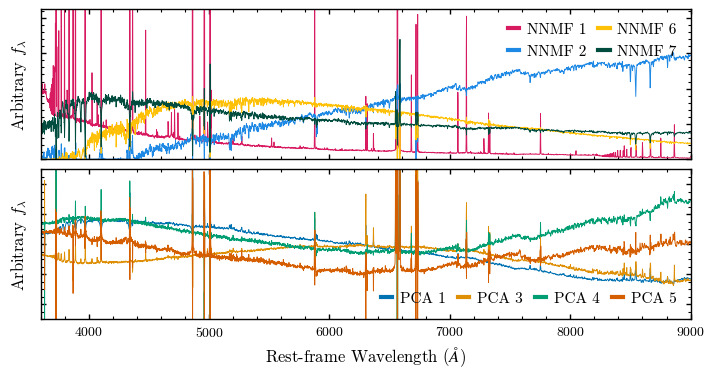

In [40]:
ax = make_tall_subplots(nrow=2, ncol=1,
                        panel_width=6.5, 
                        panel_height = 1.5,
                        row_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_PAD]
                       )

for i in range(1):
    ax[i,0].set_xticklabels([])
    ax[1,0].set_xlabel(r"Rest-frame Wavelength ($\AA$)")


top_inds  = [0, 1, 5, 6]
col_ind = 0

colors = ["#D81B60", "#1E88E5", "#FFC107", "#004D40"]

for i in top_inds:
    ax[0,0].plot(
        wave_rest,
        nnmf_temps_NEW[:, i],
        color=colors[col_ind],
        label=f"NNMF {i+1}",lw=0.65
    )
    col_ind += 1


ax[0,0].set_ylim([0,4.25])

######

bottom_inds = [0,2,3,4]
col_ind = 0

colors = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7"]

for i in bottom_inds:
    ax[1,0].plot(wave_rest,
            pca_temps_NEW[i],
            color=palette_4[col_ind],
            label=f"PCA {i+1}",lw=0.65)

    col_ind += 1

ax[1,0].set_ylim([-0.05,0.05])
locs = ["lower right","upper right"][::-1]
ncols = [4,2][::-1]
for i in range(2):
    ax[i,0].set_ylabel(r"Arbitrary $f_{\lambda}$")
    ax[i,0].set_xlim([3600,9000])

    
    leg = ax[i,0].legend(frameon=False,ncol=ncols[i],handlelength=0.75,handletextpad=0.5, columnspacing=0.8,loc=locs[i])
    
    ax[i,0].set_yticklabels([])

    for h in leg.legend_handles:
        h.set_linewidth(3)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/nnmf_pca_templates.pdf")

plt.show()

## UMAP analysis: inspect and visualize anomalies

In [15]:
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/nebular_stuff'))

from sfr_and_metallicity import line_snr_mask

In [42]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")
spec_temp_cat = Table.read(filename, hdu="SPECTRA_TEMPLATE")
fspec_cat = Table.read(filename, hdu="FASTSPEC")

print(len(data_cat))

keep_mask = spec_temp_cat["SPEC_UMAP_0"] > -50

spec_temp_cat = spec_temp_cat[keep_mask]
data_cat = data_cat[keep_mask]
fspec_cat = fspec_cat[keep_mask]

## let us remove all the objects that do have prominent emission lines!!
line_mask = line_snr_mask(fspec_cat,line_names=["HALPHA","HBETA","OIII_5007","OIII_4959", "OII_3726", "OII_3729","SII_6716"], min_lines=3, line_flux_type = "FLUX")

print(np.sum(line_mask)/len(line_mask))

spec_temp_cat = spec_temp_cat[~line_mask]
data_cat = data_cat[~line_mask]
fspec_cat = fspec_cat[~line_mask]

print(len(data_cat))


469703
0.9644503292767255
16297


In [43]:
len(fspec_cat), len(spec_temp_cat)

(16297, 16297)

In [44]:
data_cat[data_cat["TARGETID"]==39627793348170704]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,IS_BGS_BRIGHT,IS_BGS_FAINT,IS_LOWZ,IS_ELG,IS_OTHER,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,int32,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,int32,bytes13,bool,float64,float64[2],bool,bool,bool,bool,bool,bool,object,int64,bool,bytes10,int64
39627793348170704,sv1,bright,27225,0.0013074832649617519,93.58282397512812,0,0.002498415308947566,153.99276199342765,0.17599653619948805,153.99276199342765,0.17599653619948805,DESI J153.9927+00.1759,4.476583480834961,6.611087799072266,0.04088240084323658,21.011457443237305,19.48215675354004,18.595722198486328,21.011457443237305,19.48215675354004,18.595722198486328,262144,0,TRACTOR_OG,False,2.2404048442840576,0.4123784899711609 .. 144.14044189453125,False,True,False,False,False,False,[39627793348170704],39627793348170704,True,CF3_NAM,39627793348170704


In [45]:
## get all the targetids in that ball

def inspect_anomalies(spec_cat, umap_x_cen, umap_y_cen, radius_cut = 0.1):
    rads = np.sqrt( (spec_cat["SPEC_UMAP_0"].data - umap_x_cen)**2 + (spec_cat["SPEC_UMAP_1"].data - umap_y_cen)**2 )

    mask = (rads < radius_cut)

    print(f"Objects found = {np.sum(mask)}")
    
    return mask
    

##MASK_1 ARE SOME WEIRD SPECTRA DATA ANOMALIES, like poor sky subtraction etc.
mask_1 = inspect_anomalies(spec_temp_cat, 9,7, radius_cut = 0.5)

#MASK 2 is also unclear, appear like weird spectra or wrong redrock redshifts 
mask_2 = inspect_anomalies(spec_temp_cat, 8.5,8.5, radius_cut = 0.2)

mask_3 = inspect_anomalies(spec_temp_cat,8.125,8.75, radius_cut = 0.1)

mask_4 = inspect_anomalies(spec_temp_cat,6.5,7.5, radius_cut = 0.5)

#the mask 5 contains some incorrect spectra, but mostly correct spectra, we would need some additional work later to find those anomalies
mask_5 = inspect_anomalies(spec_temp_cat,6.2,8.1, radius_cut = 0.1)

mask_6 = inspect_anomalies(spec_temp_cat,3.5,13.5, radius_cut = 0.5)

# 39627821722634552  -> sometimes just a chunk of data is missing in wavelength range

Objects found = 404
Objects found = 23
Objects found = 5
Objects found = 100
Objects found = 45
Objects found = 9


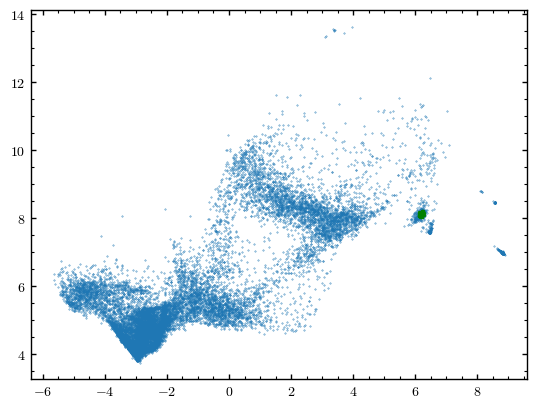

In [48]:
plt.scatter(spec_temp_cat["SPEC_UMAP_0"], spec_temp_cat["SPEC_UMAP_1"], s=0.1)

# bad_tgids = [39628023590295406, 39633476617505453, 39627392238491064, 39627462480500683]

# for tidi in bad_tgids:
#     temp = spec_temp_cat[spec_temp_cat["TARGETID"] == tidi]
#     print(temp["SPEC_UMAP_0"][0], temp["SPEC_UMAP_1"][0])
#     plt.scatter(temp["SPEC_UMAP_0"][0], temp["SPEC_UMAP_1"][0], s=10,marker="x",color="r")

# bad_tgids = [39633447987185055,39636757725057341,39636886834119964,39627984071558664]

# for tidi in bad_tgids:
#     temp = spec_temp_cat[spec_temp_cat["TARGETID"] == tidi]
#     plt.scatter(temp["SPEC_UMAP_0"][0], temp["SPEC_UMAP_1"][0], s=10,marker="x",color="darkorange")


# bad_tgids = [39627793348170704]

# for tidi in bad_tgids:
#     temp = spec_temp_cat[spec_temp_cat["TARGETID"] == tidi]
#     plt.scatter(temp["SPEC_UMAP_0"][0], temp["SPEC_UMAP_1"][0], s=10,marker="*",color="r")
    
    
# plt.xlim([-4,0])
# plt.ylim([3,6])

# plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_1], spec_temp_cat["SPEC_UMAP_1"][mask_1], s=2,color="k")
# plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_2], spec_temp_cat["SPEC_UMAP_1"][mask_2], s=2,color="k")
# plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_3], spec_temp_cat["SPEC_UMAP_1"][mask_3], s=2,color="k")
# plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_4], spec_temp_cat["SPEC_UMAP_1"][mask_4], s=2,color="k")
plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_5], spec_temp_cat["SPEC_UMAP_1"][mask_5], s=2,color="green")

# plt.xlim([5.75,7])
# plt.ylim([7,9])
plt.show()


In [49]:
spec_temp_cat[spec_temp_cat["TARGETID"] == 39627793348170704]

TARGETID,NNMF_0,NNMF_1,NNMF_2,NNMF_3,NNMF_4,NNMF_5,NNMF_6,NNMF_7,NNMF_8,NNMF_9,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,PCA_11,PCA_12,PCA_13,PCA_14,PCA_15,PCA_16,PCA_17,PCA_18,PCA_19,NNMF_NORM_FACTOR,NNMF_RESID,SPEC_UMAP_0,SPEC_UMAP_1
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627793348170704,0.0,0.3635585606098175,0.0,0.004989529959857464,0.022378429770469666,0.20973064005374908,0.0,0.08639785647392273,0.0,0.0,-143.06056213378906,-86.55628204345703,-22.03731918334961,21.128812789916992,-4.772875785827637,-9.5503511428833,0.49133366346359253,4.601698398590088,-11.099187850952148,19.221054077148438,-3.110208034515381,-3.5420961380004883,-20.360050201416016,11.722923278808594,-0.8015006184577942,-3.655068874359131,-5.723809719085693,9.002872467041016,-6.932905673980713,-13.552230834960938,0.7794193029403687,70.55054473876953,-1.8837065696716309,4.955954074859619


In [50]:
mask_6 = inspect_anomalies(spec_temp_cat,-1.883706569, 4.9559540748, radius_cut = 0.05)

##3 some wrong redshifts still exist ... 

Objects found = 14


In [51]:
data_cat[mask_6]["RA","DEC"]

RA,DEC
float64,float64
68.06502873946097,-13.341496955296359
175.4580107284506,-2.7348502976552065
190.69961856841257,-2.8520116972471974
153.99276199342765,0.17599653619948805
148.09424189229122,1.0220180103897059
221.7219521621454,11.360565481760133
249.29830441224314,14.234279014588086
116.66949858917269,18.16819443797654
37.31152873162286,28.176669685361595


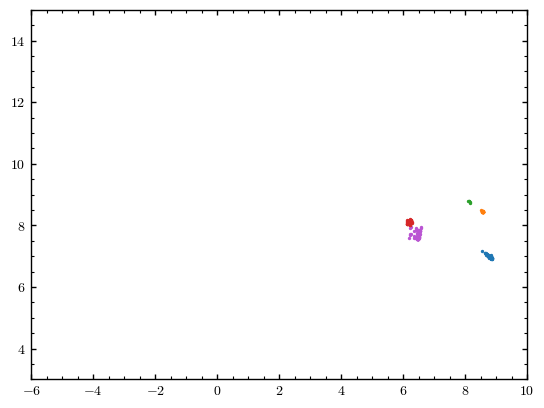

In [68]:
plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_1], spec_temp_cat["SPEC_UMAP_1"][mask_1], s=2)

plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_2], spec_temp_cat["SPEC_UMAP_1"][mask_2], s=2)

plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_3], spec_temp_cat["SPEC_UMAP_1"][mask_3], s=2)

plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_4], spec_temp_cat["SPEC_UMAP_1"][mask_4], s=2, color = "mediumorchid")

plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_5], spec_temp_cat["SPEC_UMAP_1"][mask_5], s=2)
plt.xlim([-6,10])
plt.ylim([3,15])
plt.show()

In [69]:
data_cat[mask_5]["RA","DEC"]

# let us check if any of these have a new maskbit?

RA,DEC
float64,float64
143.69304287650857,-2.5097512230806758
351.07378415437483,-2.382189826819584
127.31824509693286,-2.26683029515799
168.78261659503627,-1.4794006329830038
312.5902961875847,3.5444576847312215
170.25057718072176,4.224203286140131
353.1365576078527,5.721825972831048
25.627623742446932,7.699569647798827
214.35947782952738,8.224663803209934


In [55]:
mask_1_tgids = spec_temp_cat[mask_1]["TARGETID"].data
mask_2_tgids = spec_temp_cat[mask_2]["TARGETID"].data
mask_3_tgids = spec_temp_cat[mask_3]["TARGETID"].data
mask_4_tgids = spec_temp_cat[mask_4]["TARGETID"].data

mask_1_specmask = np.isin(tgids, mask_1_tgids)
mask_2_specmask = np.isin(tgids, mask_2_tgids)
mask_3_specmask = np.isin(tgids, mask_3_tgids)
mask_4_specmask = np.isin(tgids, mask_4_tgids)


In [56]:
spec_mask_4 =  np.median(flux_norm[:,mask_4_specmask],axis=1)
spec_mask_3 =  np.median(flux_norm[:,mask_3_specmask],axis=1)
spec_mask_2 =  np.median(flux_norm[:,mask_2_specmask],axis=1)
spec_mask_1 =  np.median(flux_norm[:,mask_1_specmask],axis=1)



In [57]:

from desi_lowz_funcs import save_jpg
import requests

save_jpg_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/jpg_imgs"

def get_rgbs(tgids=[39633447987185055,39636757725057341,39636886834119964,39627984071558664],cutout_arcsec=12):
    '''
    Function that returns the RGB elements
    '''

    cutout_size = cutout_arcsec/0.262

    print(int(cutout_size))
    
    session = requests.Session()

    all_paths = []
    all_zreds = []
    all_radec = []
    
    for tgidi in tgids:
        data_cat_i = data_cat[data_cat["TARGETID"] == tgidi]
        ra_i = data_cat_i["RA"][0]
        dec_i = data_cat_i["DEC"][0]
        img_path_i = f"{save_jpg_path}/img_{tgidi}.jpg" 
        save_jpg(ra_i,dec_i,img_path_i,session, size=int(cutout_size) )
        all_paths.append(img_path_i)
        all_zreds.append(data_cat_i["Z"][0])
        all_radec.append(f"({ra_i:.2f},{dec_i:.2f})")

    return all_paths, all_zreds, all_radec, tgids


In [58]:
mask_1_tgids[:5]

array([39627152924085203, 39627335128849091, 39627420659095662,
       39627479568090005, 39627514422755521], dtype='>i8')

In [59]:
import matplotlib.image as mpimg

paths_mask1, z_mask1, radec_mask1, tgids_mask1 = get_rgbs(tgids=mask_1_tgids[:5],cutout_arcsec=10)



38


In [60]:
paths_mask2, z_mask2, radec_mask2, tgids_mask2 = get_rgbs(tgids=mask_2_tgids[:5],cutout_arcsec=10)
paths_mask4, z_mask4, radec_mask4, tgids_mask4 = get_rgbs(tgids=mask_4_tgids[:5],cutout_arcsec=10)


38
38


In [75]:
mask_4_tgids[:5]

array([39627486031516987, 39627497746205907, 39627497817505927,
       39627538091215795, 39627599143501933], dtype='>i8')

In [62]:
rgb_imgs_1 = [mpimg.imread(p) for p in paths_mask1]
rgb_imgs_2 = [mpimg.imread(p) for p in paths_mask2]
rgb_imgs_4 = [mpimg.imread(p) for p in paths_mask4]


In [63]:
all_rgbs = [ rgb_imgs_1, rgb_imgs_2, rgb_imgs_4 ]

In [64]:
all_zs = [z_mask1, z_mask2, z_mask4]

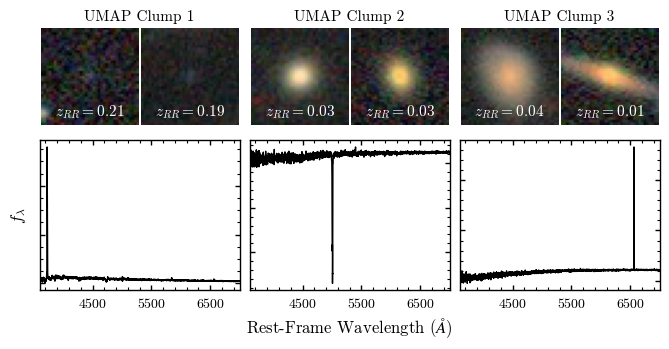

In [78]:

# -----------------------------
# Main figure
# -----------------------------
fig, ax = make_tall_subplots(nrow=1, 
                        ncol=3, 
                        return_fig=True,
                        panel_width=2, 
                        panel_height = 1.5,
                        row_spacing = [MARGIN_LABEL, MARGIN_LABEL],
                        col_spacing = [MARGIN_LABEL, MARGIN_SHARED,MARGIN_SHARED, MARGIN_PAD],
                            )

ax[0,2].plot(wave_rest, spec_mask_4, color="k", lw=1)
ax[0,1].plot(wave_rest, spec_mask_2, color="k", lw=1)
ax[0,0].plot(wave_rest, spec_mask_1, color="k", lw=1)


for axi in ax[0]:
    axi.set_xlim([3600, 7000])
    axi.set_yticklabels([])

    ax[0,1].set_xlabel(r"Rest-Frame Wavelength ($\AA$)")
    axi.set_xticks([4500,5500,6500])

ax[0,0].set_ylabel(r"$f_{\lambda}$")

fig.canvas.draw()  # forces the divider to resolve all positions


##let us loop over all the axes

for ax_ind in range(3):

    # Get the rightmost panel's bounding box in figure fraction
    bbox = ax[0,ax_ind].get_position()  # Bbox in figure coords
    
    # Image params
    n_img = 2
    img_height_frac = 0.295  # fraction of figure height — tune this
    img_width_frac  = bbox.width / n_img  # each image gets half the panel width
    
    # Vertically: sit just inside the panel, near the bottom
    img_bottom = bbox.y0 + .5  # small offset from panel bottom edge
    
    # Horizontally: center the block of n_img images over ax[2]
    block_width = img_width_frac * n_img
    img_left = bbox.x0 + (bbox.width - block_width) / 2  # centered
    
    for i in range(n_img):
        ax_img = fig.add_axes([
            img_left + i * img_width_frac,
            img_bottom,
            img_width_frac,
            img_height_frac,
        ])
        ax_img.imshow(all_rgbs[ax_ind][i], origin="lower")
        ax_img.axis("off")
        ax_img.set_aspect("equal")
        ax_img.text(
            0.5, 0.05, r"$z_{RR}=$" f"{all_zs[ax_ind][i]:.2f}",
            transform=ax_img.transAxes,
            ha="center", va="bottom",
            color="white",
        )


ax[0,0].text(0.5,1.8,r"UMAP Clump 1",color="k",transform=ax[0,0].transAxes,ha="center" )

ax[0,1].text(0.5,1.8,r"UMAP Clump 2",color="k",transform=ax[0,1].transAxes,ha="center" )

ax[0,2].text(0.5,1.8,r"UMAP Clump 3",color="k",transform=ax[0,2].transAxes,ha="center" )

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/umap_anomaly_wrong_zrr.pdf")

plt.show()


In [73]:
## what are the TARGETIDs of these examples ..

## Plotting the UMAP plot!!

In [7]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")
spec_temp_cat = Table.read(filename, hdu="SPECTRA_TEMPLATE")
fspec_cat = Table.read(filename, hdu="SPEC_DERIVED")

keep_mask = spec_temp_cat["SPEC_UMAP_0"] > -50

spec_temp_cat = spec_temp_cat[keep_mask]
data_cat = data_cat[keep_mask]
fspec_cat = fspec_cat[keep_mask]


In [8]:
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm

def get_edges_counts(spec_cat,mask):
    n_bins = 200
    temp = spec_cat[mask]
    hist, xedges, yedges = np.histogram2d(temp["SPEC_UMAP_0"], temp["SPEC_UMAP_1"], bins=n_bins) 
    # Step 3: Calculate the number of points in each bin
    counts, _, _ = np.histogram2d(temp["SPEC_UMAP_0"], temp["SPEC_UMAP_1"], bins=n_bins)
    return xedges, yedges, counts

elg_mask = (data_cat["IS_ELG"] == True)
no_elg_mask = (data_cat["IS_ELG"] != True)

xedges_elg, yedges_elg, counts_elg = get_edges_counts(spec_temp_cat,elg_mask)
xedges_noelg, yedges_noelg, counts_noelg = get_edges_counts(spec_temp_cat,no_elg_mask)

frac = len(counts_elg)/len(counts_noelg)
counts_elg = counts_elg/frac

counts_elg_m = np.ma.masked_where(counts_elg <= 5, counts_elg)
counts_noelg_m = np.ma.masked_where(counts_noelg <= 1, counts_noelg)

In [9]:
from matplotlib.patches import FancyBboxPatch, Rectangle

def add_dashed_box(ax, x0, y0, width, height, **kwargs):
    """
    Add a dashed rectangle to an axes.
    
    Parameters
    ----------
    ax     : matplotlib axes
    x0, y0 : float — bottom-left corner in data coordinates
    width  : float — box width in data coordinates
    height : float — box height in data coordinates
    **kwargs: passed to Rectangle (override defaults)
    """
    defaults = dict(linewidth=0.6, edgecolor="black", facecolor="none",
                    linestyle="--", zorder=5)
    defaults.update(kwargs)
    ax[0].add_patch(Rectangle((x0, y0), width, height, **defaults))

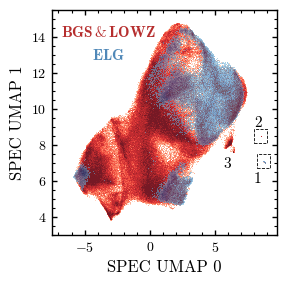

In [10]:

ax = make_subplots(ncol=1,
                   nrow=1,plot_size=2.25, row_spacing=[MARGIN_LABEL, MARGIN_PAD], 
                   col_spacing=[MARGIN_LABEL, MARGIN_PAD] )

cmap_elg = plt.cm.Blues.copy()
cmap_elg.set_bad(alpha=0.0)

cmap_noelg = plt.cm.Reds.copy()
cmap_noelg.set_bad(alpha=0.0)

minc=1
maxc=45

ax[0].pcolormesh(xedges_noelg, yedges_noelg, counts_noelg_m.T, shading='auto', 
                 cmap=cmap_noelg,norm=LogNorm(vmin=minc,vmax=maxc),
                 rasterized=True,alpha=0.9)

ax[0].pcolormesh(xedges_elg, yedges_elg, counts_elg_m.T, shading='auto', 
                 cmap=cmap_elg,norm=LogNorm(vmin=minc,vmax=maxc),
                 rasterized=True,alpha=0.55)

ax[0].text(0.25,0.78,r"$\mathbf{ELG}$",transform=ax[0].transAxes,
           color="steelblue",alpha=0.95,weight="bold",ha="center")
ax[0].text(0.25,0.88,r"$\mathbf{BGS\,&\,LOWZ}$",transform=ax[0].transAxes,
           color="firebrick",weight="bold",alpha=0.95,ha="center")

ax[0].set_xlim([-7.5,9.75])
ax[0].set_ylim([3,15.5])

ax[0].set_xlabel(r"SPEC UMAP 0")
ax[0].set_ylabel(r"SPEC UMAP 1")


## denote the islands by some number?

ax[0].text(7.9,5.9,r"$1$",color="k")

ax[0].text(8,9,r"$2$",color="k")

ax[0].text(5.65,6.75,r"$3$",color="k")

#maybe draw a box around the regions?
add_dashed_box(ax, x0=8.2, y0=6.7, width=1, height=0.75)

add_dashed_box(ax, x0=8, y0=8.1, width=1, height=0.75)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/umap_spectra_sample.pdf")
plt.show()

In [11]:
## let us stack the spectra in those three clumps?
spec_elg = spec_temp_cat[elg_mask]

cx1,cy1 = -5,6
cx2,cy2 = 2,5.5
cx3,cy3 = 5,11


In [12]:
radius_1 = np.sqrt( (spec_elg["SPEC_UMAP_0"] - cx1)**2 + (spec_elg["SPEC_UMAP_1"] - cy1)**2 )
radius_2 = np.sqrt( (spec_elg["SPEC_UMAP_0"] - cx2)**2 + (spec_elg["SPEC_UMAP_1"] - cy2)**2 )
radius_3 = np.sqrt( (spec_elg["SPEC_UMAP_0"] - cx3)**2 + (spec_elg["SPEC_UMAP_1"] - cy3)**2 )


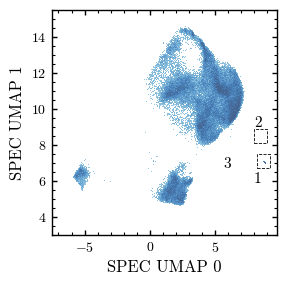

In [13]:

ax = make_subplots(ncol=1,
                   nrow=1,plot_size=2.25, row_spacing=[MARGIN_LABEL, MARGIN_PAD], 
                   col_spacing=[MARGIN_LABEL, MARGIN_PAD] )

cmap_elg = plt.cm.Blues.copy()
cmap_elg.set_bad(alpha=0.0)

minc=1
maxc=45

ax[0].pcolormesh(xedges_elg, yedges_elg, counts_elg_m.T, shading='auto', 
                 cmap=cmap_elg,norm=LogNorm(vmin=minc,vmax=maxc),
                 rasterized=True,alpha=0.75)

ax[0].set_xlim([-7.5,9.75])
ax[0].set_ylim([3,15.5])

ax[0].set_xlabel(r"SPEC UMAP 0")
ax[0].set_ylabel(r"SPEC UMAP 1")


## denote the islands by some number?

ax[0].text(7.9,5.9,r"$1$",color="k")

ax[0].text(8,9,r"$2$",color="k")

ax[0].text(5.65,6.75,r"$3$",color="k")

#maybe draw a box around the regions?
add_dashed_box(ax, x0=8.2, y0=6.7, width=1, height=0.75)

add_dashed_box(ax, x0=8, y0=8.1, width=1, height=0.75)

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/umap_spectra_sample.pdf")
plt.show()

## Three broad ELG UMAP regions: stacked spectra & redshift distributions

The ELG-only SPEC UMAP shows three broad, distinct regions: the isolated lower-left blob (~ -5, 6), the bottom-center blob (~ 2, 5.5), and the large top structure (~ 5, 11). Below we select each with a rough circle, then compare their median-stacked rest-frame spectra and redshift distributions to see how the spectra differ.

Region 1: center=(-5,6) r=1.5  ->  4977 objects
Region 2: center=(2,5.5) r=1.5  ->  20419 objects
Region 3: center=(5.5,10.5) r=1.5  ->  47352 objects


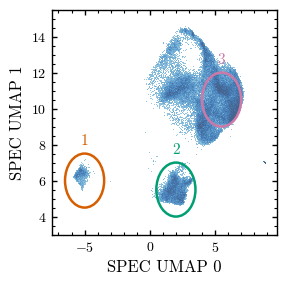

In [14]:
## ---- Three broad ELG UMAP regions: setup + circle overlay ----
from matplotlib.patches import Circle

# ELG-only subset (spec_temp_cat and data_cat are row-matched)
elg_mask = (data_cat["IS_ELG"] == True)
spec_elg = spec_temp_cat[elg_mask]
data_elg = data_cat[elg_mask]

# region centers (SPEC_UMAP_0, SPEC_UMAP_1), radii, colors (Wong colorblind)
region_cens   = [(-5.0, 6.0), (2.0, 5.5), (5.5, 10.5)]
region_radii  = [1.5, 1.5, 1.5]
region_colors = ["#D55E00", "#009E73", "#CC79A7"]   # vermillion / green / purple
region_labels = ["1", "2", "3"]

# circular membership masks on the ELG subset
_ux = spec_elg["SPEC_UMAP_0"].data
_uy = spec_elg["SPEC_UMAP_1"].data
region_masks = []
for (cx, cy), r, lab in zip(region_cens, region_radii, region_labels):
    m = np.sqrt((_ux - cx)**2 + (_uy - cy)**2) < r
    region_masks.append(m)
    print(f"Region {lab}: center=({cx:g},{cy:g}) r={r:g}  ->  {np.sum(m)} objects")

# ---- UMAP with the three circles drawn ----
ax = make_subplots(ncol=1, nrow=1, plot_size=2.25,
                   row_spacing=[MARGIN_LABEL, MARGIN_PAD],
                   col_spacing=[MARGIN_LABEL, MARGIN_PAD])

cmap_elg = plt.cm.Blues.copy()
cmap_elg.set_bad(alpha=0.0)

ax[0].pcolormesh(xedges_elg, yedges_elg, counts_elg_m.T, shading='auto',
                 cmap=cmap_elg, norm=LogNorm(vmin=1, vmax=45),
                 rasterized=True, alpha=0.75)

for (cx, cy), r, col, lab in zip(region_cens, region_radii, region_colors, region_labels):
    ax[0].add_patch(Circle((cx, cy), r, edgecolor=col, facecolor="none",
                           lw=1.8, zorder=6))
    ax[0].text(cx, cy + r + 0.35, lab, color=col, ha="center", va="bottom",
               weight="bold")

ax[0].set_xlim([-7.5, 9.75])
ax[0].set_ylim([3, 15.5])
ax[0].set_xlabel(r"SPEC UMAP 0")
ax[0].set_ylabel(r"SPEC UMAP 1")

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/umap_elg_regions.pdf")
plt.show()

In [ ]:
## ---- Plot A: full median-stacked spectra, one panel per ELG region ----
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/plots'))
from line_labels import LINES, label_lines

# wave_rest is a VACUUM rest-frame grid (DESI coadd wave / (1+z), no air conv;
# see nnmf_analysis.deredshift_resample_desi_spectra), so shift the AIR line
# list to vacuum. Flip to False if the ticks look ~1.5 A off.
AIR_TO_VAC = True

WAVE_LO, WAVE_HI = 3600, 7000
in_x = (wave_rest >= WAVE_LO) & (wave_rest <= WAVE_HI)

# inset zoom window: blue end (continuum + weak blue lines squashed by shared y)
INS_LO, INS_HI = 3600, 4500
in_ins = (wave_rest >= INS_LO) & (wave_rest <= INS_HI)

# median-stack each region (FLUX_NORM is already amplitude-normalized -> the
# stacks share a common scale, so continuum shape + line strengths compare 1:1)
region_stacks = []
for m, lab in zip(region_masks, region_labels):
    reg_tgids = spec_elg[m]["TARGETID"].data
    specmask  = np.isin(tgids, reg_tgids)              # flux_norm columns for this region
    stack     = np.median(flux_norm[:, specmask], axis=1)
    region_stacks.append(stack)
    print(f"Region {lab}: {np.sum(specmask)} spectra stacked")

# shared y-limits across the 3 main panels (driven by the brightest lines)
ymin = min(s[in_x].min() for s in region_stacks)
ymax = max(s[in_x].max() for s in region_stacks)
ypad = 0.05 * (ymax - ymin)

# shared y-limits across the 3 insets (blue end), with top headroom for labels
ins_ymin = min(s[in_ins].min() for s in region_stacks)
ins_ymax = max(s[in_ins].max() for s in region_stacks)
ins_rng  = ins_ymax - ins_ymin
ins_lo   = ins_ymin - 0.05 * ins_rng
ins_hi   = ins_ymin + ins_rng / 0.62               # peaks fill ~62%, top ~38% for labels

# short line labels for the (small) inset, drawn INSIDE with no connectors
inset_lab = {"OII3726": r"[OII]", "NeIII3869": r"[NeIII]", "Hdelta": r"H$\delta$",
             "Hgamma": r"H$\gamma$", "OIII4363": r"4363"}
inset_dx  = {"OIII4363": +45.0}                    # nudge off Hgamma
inset_style = {ln.id: dict(noline=True, label=inset_lab.get(ln.id, ln.label),
                           dx=inset_dx.get(ln.id, 0.0))
               for ln in LINES if ln.strong}

ax = make_tall_subplots(nrow=3, ncol=1, panel_width=6.5, panel_height=1.3,
                        row_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_SHARED, MARGIN_LABEL],
                        col_spacing=[MARGIN_LABEL, MARGIN_PAD])

for i, (stack, col, lab) in enumerate(zip(region_stacks, region_colors, region_labels)):
    axi = ax[i, 0]
    axi.plot(wave_rest, stack, color=col, lw=0.8)
    axi.set_xlim([WAVE_LO, WAVE_HI])
    axi.set_ylim([ymin - ypad, ymax + ypad])
    axi.set_ylabel(r"$f_{\lambda}$ (norm.)")
    # region label at the right edge (nudge manually later if needed)
    axi.text(0.985, 0.90, f"Region {lab}", transform=axi.transAxes,
             color=col, weight="bold", ha="right", va="top")
    if i < 2:
        axi.set_xticklabels([])

    # ---- inset: blue-end zoom (3600-4500), shared y across the 3 panels ----
    axins = axi.inset_axes([0.055, 0.42, 0.48, 0.55])
    axins.plot(wave_rest, stack, color=col, lw=0.7)
    axins.set_xlim([INS_LO, INS_HI])
    axins.set_ylim([ins_lo, ins_hi])
    axins.set_xticks([3700, 4000, 4300])
    axins.set_yticks([])
    axins.tick_params(labelsize=4.5, length=2, pad=1.5)
    label_lines(axins, strong_only=True, exclude=["wr", "highion"],
                style=inset_style, air_to_vacuum=AIR_TO_VAC,
                fiducial=0.66, angle=90, stagger=False, fontsize=4.5, color="0.25")

ax[2, 0].set_xlabel(r"Rest-Frame Wavelength ($\AA$)")

# strong nebular line IDs above the top panel (x is shared down the column)
strong_style = {ln.id: dict(loc="top") for ln in LINES if ln.strong}
label_lines(ax[0, 0], strong_only=True, exclude=["wr", "highion"],
            style=strong_style, air_to_vacuum=AIR_TO_VAC,
            top_angle=90, fontsize=6, color="0.25")

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/umap_elg_regions_spectra_panels.pdf")
plt.show()


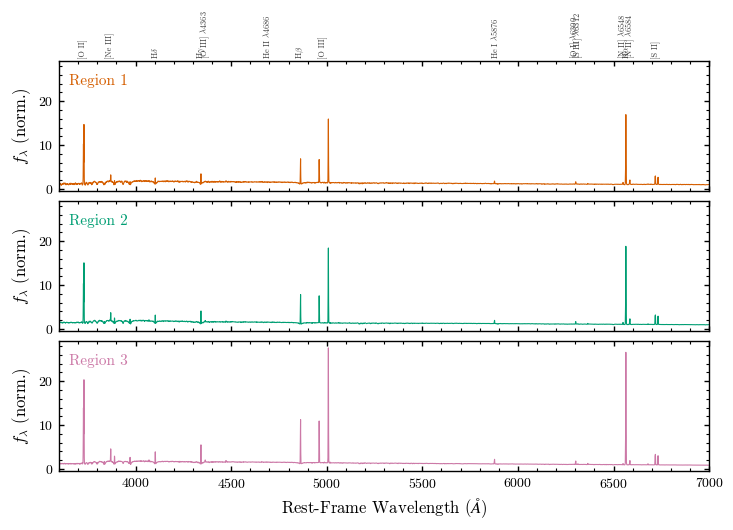

In [27]:
# shared y-limits across the 3 panels (driven by the brightest lines)
ymin = min(s[in_x].min() for s in region_stacks)
ymax = max(s[in_x].max() for s in region_stacks)
ypad = 0.05 * (ymax - ymin)

ax = make_tall_subplots(nrow=3, ncol=1, panel_width=6.5, panel_height=1.3,
                        row_spacing=[MARGIN_LABEL, MARGIN_SHARED, MARGIN_SHARED, MARGIN_LABEL],
                        col_spacing=[MARGIN_LABEL, MARGIN_PAD])

for i, (stack, col, lab) in enumerate(zip(region_stacks, region_colors, region_labels)):
    ax[i, 0].plot(wave_rest, stack, color=col, lw=0.8)
    ax[i, 0].set_xlim([WAVE_LO, WAVE_HI])
    ax[i, 0].set_ylim([ymin - ypad, ymax + ypad + 0.2])
    ax[i, 0].set_ylabel(r"$f_{\lambda}$ (norm.)")
    ax[i, 0].text(0.015, 0.90, f"Region {lab}", transform=ax[i, 0].transAxes,
                  color=col, weight="bold", ha="left", va="top")
    if i < 2:
        ax[i, 0].set_xticklabels([])

ax[2, 0].set_xlabel(r"Rest-Frame Wavelength ($\AA$)")

# strong nebular line IDs above the top panel (x is shared down the column)
strong_style = {ln.id: dict(loc="top") for ln in LINES if ln.strong}
label_lines(ax[0, 0], strong_only=True, exclude=["wr", "highion"],
            style=strong_style, air_to_vacuum=AIR_TO_VAC,
            top_angle=90, fontsize=6, color="0.25")

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/umap_elg_regions_spectra_panels.pdf")
plt.show()

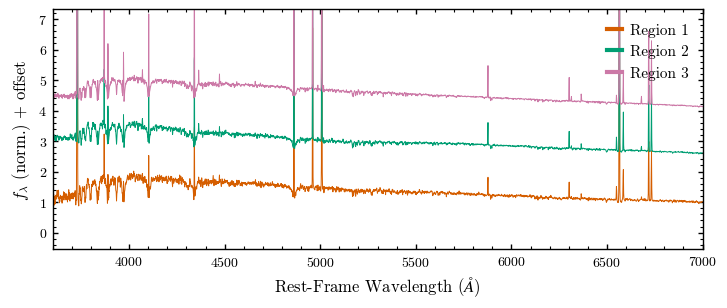

In [20]:
## ---- Plot B: offset overlay, zoomed to the continuum + weak emission lines ----
## (depends on region_stacks / AIR_TO_VAC from Plot A above; bright lines like
##  [OIII], Halpha, Hbeta run off the top of the zoom -- that is intended)
from line_labels import label_lines

WAVE_LO, WAVE_HI = 3600, 7000
in_x = (wave_rest >= WAVE_LO) & (wave_rest <= WAVE_HI)

# per-region continuum level (median flux) sets sensible offset + zoom defaults
cont = np.array([np.median(s[in_x]) for s in region_stacks])
base = float(np.median(cont))

offset_step = 1.2 * base                      # vertical separation between regions  (tune me)
y_lo        = -0.4 * base                      # bottom of the zoom
y_hi        = 2 * offset_step + 3.0 * base     # top of the zoom (clips the bright lines)

ax = make_tall_subplots(nrow=1, ncol=1, panel_width=6.5, panel_height=2.4,
                        row_spacing=[MARGIN_LABEL, MARGIN_LABEL],
                        col_spacing=[MARGIN_LABEL, MARGIN_PAD])

for i, (stack, col, lab) in enumerate(zip(region_stacks, region_colors, region_labels)):
    ax[0, 0].plot(wave_rest, stack + i * offset_step, color=col, lw=0.7,
                  label=f"Region {lab}")

ax[0, 0].set_xlim([WAVE_LO, WAVE_HI])
ax[0, 0].set_ylim([y_lo, y_hi])
ax[0, 0].set_xlabel(r"Rest-Frame Wavelength ($\AA$)")
ax[0, 0].set_ylabel(r"$f_{\lambda}$ (norm.) $+$ offset")

leg = ax[0, 0].legend(frameon=False, handlelength=1.0, handletextpad=0.5, loc="upper right")
for h in leg.legend_handles:
    h.set_linewidth(3)

# label a broad set of nebular lines (incl. weak ones) above the panel, with
# light vertical guides so faint features line up across the offset traces.
# placed = label_lines(ax[0, 0],
#                      categories=["balmer", "oxygen", "forbidden", "helium"],
#                      air_to_vacuum=AIR_TO_VAC, top_angle=90, fontsize=5.5,
#                      color="0.25")
# for _kind, xline, _y in placed.values():
#     ax[0, 0].axvline(xline, color="0.85", lw=0.4, zorder=0)

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/umap_elg_regions_spectra_offset.pdf")
plt.show()

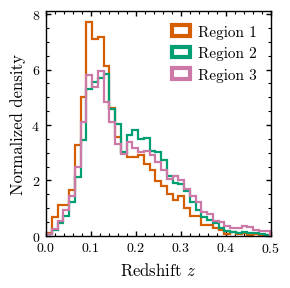

In [21]:
## ---- Redshift distributions of the three ELG regions ----
ax = make_subplots(ncol=1, nrow=1, plot_size=2.25,
                   row_spacing=[MARGIN_LABEL, MARGIN_PAD],
                   col_spacing=[MARGIN_LABEL, MARGIN_PAD])

# common bins across the three selections for a fair density comparison
z_all = np.concatenate([data_elg[m]["Z"].data for m in region_masks])
zbins = np.linspace(np.min(z_all), np.max(z_all), 40)

for m, col, lab in zip(region_masks, region_colors, region_labels):
    ax[0].hist(data_elg[m]["Z"].data, bins=zbins, density=True,
               histtype="step", lw=1.6, color=col, label=f"Region {lab}")

ax[0].set_xlim([0,0.5])

ax[0].set_xlabel(r"Redshift $z$")
ax[0].set_ylabel("Normalized density")
leg = ax[0].legend(frameon=False, handlelength=1.2, handletextpad=0.5)
for h in leg.legend_handles:
    h.set_linewidth(3)

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/umap_elg_regions_zdist.pdf")
plt.show()

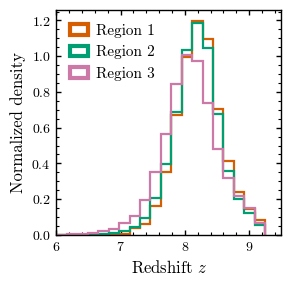

In [22]:
## ---- Redshift distributions of the three ELG regions ----
ax = make_subplots(ncol=1, nrow=1, plot_size=2.25,
                   row_spacing=[MARGIN_LABEL, MARGIN_PAD],
                   col_spacing=[MARGIN_LABEL, MARGIN_PAD])

# common bins across the three selections for a fair density comparison
z_all = np.concatenate([data_elg[m]["LOG_MSTAR_M24"].data for m in region_masks])
zbins = np.linspace(np.min(z_all), np.max(z_all), 40)

for m, col, lab in zip(region_masks, region_colors, region_labels):
    ax[0].hist(data_elg[m]["LOG_MSTAR_M24"].data, bins=zbins, density=True,
               histtype="step", lw=1.6, color=col, label=f"Region {lab}")

ax[0].set_xlim([6,9.5])

ax[0].set_xlabel(r"Redshift $z$")
ax[0].set_ylabel("Normalized density")
leg = ax[0].legend(frameon=False, handlelength=1.2, handletextpad=0.5)
for h in leg.legend_handles:
    h.set_linewidth(3)

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/umap_elg_regions_zdist.pdf")
plt.show()